In [1]:
import numpy as np
import linearsolve as ls
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline

In [2]:
import fredpy as fp
fp.api_key = fp.load_api_key('fred_api_key.txt')

## The Taylor Rule

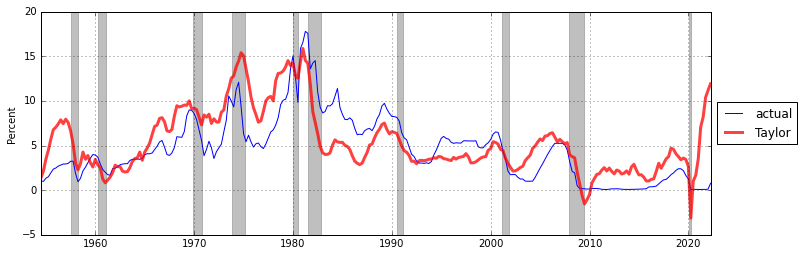

In [3]:
# Download federal funds rate, real GDP, GDP deflator, and potential real GDP 
ffr = fp.series('FEDFUNDS')
gdp = fp.series('GDPC1')
deflator = fp.series('GDPDEF')
potential_gdp = fp.series('GDPPOT')

# Convert monthly ffr data to quarterly
ffr = ffr.as_frequency('Q')

# Compute annual inflation rate
inflation = deflator.apc()

# Make sure all data have the same data intervals
inflation, gdp, potential_gdp, ffr = fp.window_equalize([inflation, gdp, potential_gdp, ffr])

# Construct output gap measure
gap = (gdp.data - potential_gdp.data)/potential_gdp.data*100

# Compute Taylor rule
taylor_rule = inflation.data + 2 + 0.5*(inflation.data-2) + 0.5*gap

# Plot results
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,1,1)
ax.plot(ffr.data,label='actual')
ax.plot(taylor_rule,'r',lw=3,alpha=0.75,label='Taylor')
ffr.recessions()
ax.grid()
ax.set_ylabel('Percent')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

## Solution

In [4]:
# Input model parameters
parameters = pd.Series(dtype=float)
parameters['y_bar'] = 0
parameters['beta'] = 0.995
parameters['r_bar'] = -np.log(parameters.beta)
parameters['kappa'] = 0.25
parameters['pi_T'] = 0.02/4
parameters['phi_pi'] = 1.5
parameters['phi_y'] = 0.5/4
parameters['rho_g'] = 0.5
parameters['rho_u'] = 0.5
parameters['rho_v'] = 0.5

parameters['sigma_g'] = 0.015
parameters['sigma_v'] = 0.001
parameters['sigma_u'] = 0.003



# Function that evaluates the equilibrium conditions
def equilibrium_equations(variables_forward,variables_current,parameters):
    
    # Parameters 
    p = parameters
    
    # Variables
    fwd = variables_forward
    cur = variables_current

    # IS equation
    is_equation = fwd.y - (cur.r-p.r_bar) + cur.g - cur.y
    
    # Fisher_equation
    fisher_equation = cur.r + fwd.pi - cur.i
    
    # Monetary policy
    monetary_policy = p.r_bar + p.pi_T + p.phi_pi*(cur.pi-p.pi_T) + p.phi_y*(cur.y - p.y_bar) + cur.v - cur.i
    
    # Phillips curve
    phillips_curve = p.beta*(fwd.pi-p.pi_T) + p.kappa*(cur.y - p.y_bar) + cur.u - (cur.pi-p.pi_T)
    
    # Demand process
    demand_process = p.rho_g*cur.g - fwd.g
    
    # Monetary policy process
    monetary_policy_process = p.rho_v*cur.v - fwd.v
    
    # Inflation process
    inflation_process = p.rho_u*cur.u - fwd.u
    
    
    # Stack equilibrium conditions into a numpy array
    return np.array([
            is_equation,
            fisher_equation,
            monetary_policy,
            phillips_curve,
            demand_process,
            monetary_policy_process,
            inflation_process
        ])

# Initialize the model
model = ls.model(equations = equilibrium_equations,
                 n_states=3,
                 n_exo_states=3,
                 var_names=['g','v','u','y','pi','i','r'],
                 parameters = parameters)

# Compute the steady state numerically
guess = [0,0,0,0,0.02/4,0.00,0.00]
model.compute_ss(guess)

# Find the log-linear approximation around the non-stochastic steady state and solve
model.approximate_and_solve(log_linear=False)

# Compute impulse responses and plot
model.impulse(T=21,t0=5,shocks=[0.01,0.01/4,0.01/4])

print(model.approximated())

Linear equilibrium conditions:

       y[t+1|t] = -g[t]+y[t]+r[t]

      pi[t+1|t] = i[t]-r[t]

              0 = -v[t]-0.125·y[t]-1.5·pi[t]+i[t]

0.995·pi[t+1|t] = -u[t]-0.25·y[t]+pi[t]

        -g[t+1] = -0.5·g[t]

        -v[t+1] = -0.5·v[t]

        -u[t+1] = -0.5·u[t]


## Impulse Responses

### Demand Shock

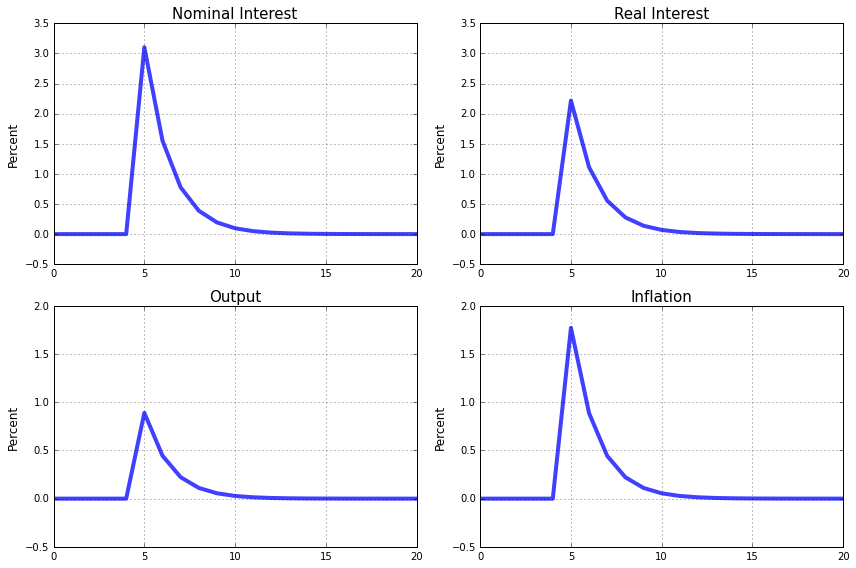

In [5]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

ax1.set_ylabel('Percent',fontsize=12)
ax2.set_ylabel('Percent',fontsize=12)
ax3.set_ylabel('Percent',fontsize=12)
ax4.set_ylabel('Percent',fontsize=12)

ax1.set_title('Nominal Interest',fontsize=15)
ax2.set_title('Real Interest',fontsize=15)
ax3.set_title('Output',fontsize=15)
ax4.set_title('Inflation',fontsize=15)

(model.irs['e_g']['i']*400).plot(ax=ax1,lw=4,alpha=0.75,grid=True)
(model.irs['e_g']['r']*400).plot(ax=ax2,lw=4,alpha=0.75,grid=True)
(model.irs['e_g']['y']*100).plot(ax=ax3,lw=4,alpha=0.75,grid=True)
(model.irs['e_g']['pi']*400).plot(ax=ax4,lw=4,alpha=0.75,grid=True)

ax1.set_ylim([-0.5,3.5])
ax2.set_ylim([-0.5,3.5])
ax3.set_ylim([-0.5,2])
ax4.set_ylim([-0.5,2])

fig.tight_layout()

# Save image and make LaTex figure
figName = '015_intro_nk_modeling_demand_shock'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120,transparent=True)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Aggregate demand shock.} Impulse responses \
of the exogenous component of demand, the nominal interest rate, output, and inflation to a one percent shock to the \
exogenous component of aggregate demand. Inflation and interest rates are annualized.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 9cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

In [6]:
print(model.irs['e_g'][['y']].abs().max()*100)
print(model.irs['e_g'][['i','r','pi']].abs().max()*400)

y    0.890859
dtype: float64
i     3.104709
r     2.218283
pi    1.772853
dtype: float64


### Inflation Shock

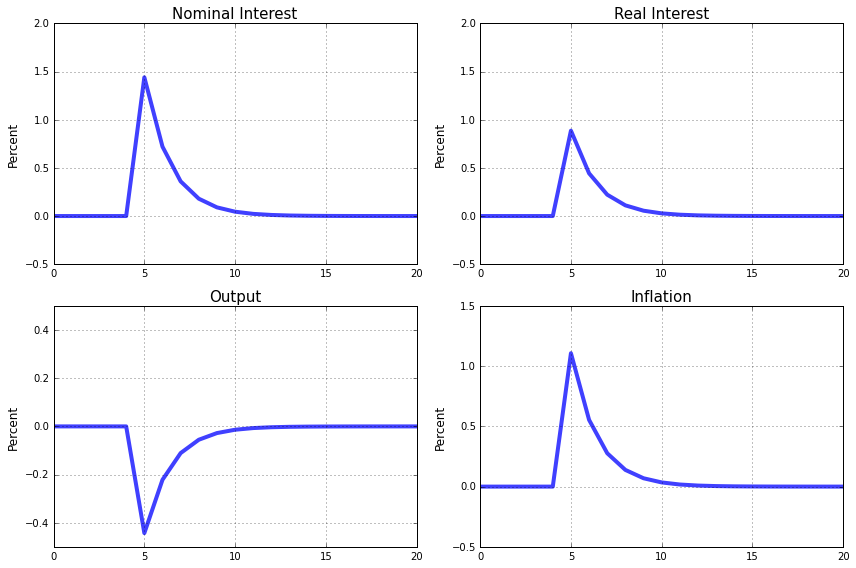

In [7]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)
ax1.set_ylabel('Percent',fontsize=12)
ax2.set_ylabel('Percent',fontsize=12)
ax3.set_ylabel('Percent',fontsize=12)
ax4.set_ylabel('Percent',fontsize=12)

ax1.set_title('Nominal Interest',fontsize=15)
ax2.set_title('Real Interest',fontsize=15)
ax3.set_title('Output',fontsize=15)
ax4.set_title('Inflation',fontsize=15)

(model.irs['e_u']['i']*400).plot(ax=ax1,lw=4,alpha=0.75,grid=True)
(model.irs['e_u']['r']*400).plot(ax=ax2,lw=4,alpha=0.75,grid=True)
(model.irs['e_u']['y']*100).plot(ax=ax3,lw=4,alpha=0.75,grid=True)
(model.irs['e_u']['pi']*400).plot(ax=ax4,lw=4,alpha=0.75,grid=True)

ax1.set_ylim([-.5,2])
ax2.set_ylim([-0.5,2])
ax3.set_ylim([-0.5,0.5])
ax4.set_ylim([-0.5,1.5])

fig.tight_layout()

# Save image and make LaTex figure
figName = '015_intro_nk_modeling_inflation_shock'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120,transparent=True)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Inflation shock.} Impulse responses \
of the exogenous component of inflation, the nominal interest rate, output, and inflation to a 0.25 percent shock to the \
exogenous component of inflation. Inflation and interest rates are annualized.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 9cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

In [8]:
print(model.irs['e_u'][['y']].abs().max()*100)
print(model.irs['e_u'][['i','r','pi']].abs().max()*400)

y    0.443213
dtype: float64
i     1.440443
r     0.886427
pi    1.108033
dtype: float64


### Monetary Policy Shock

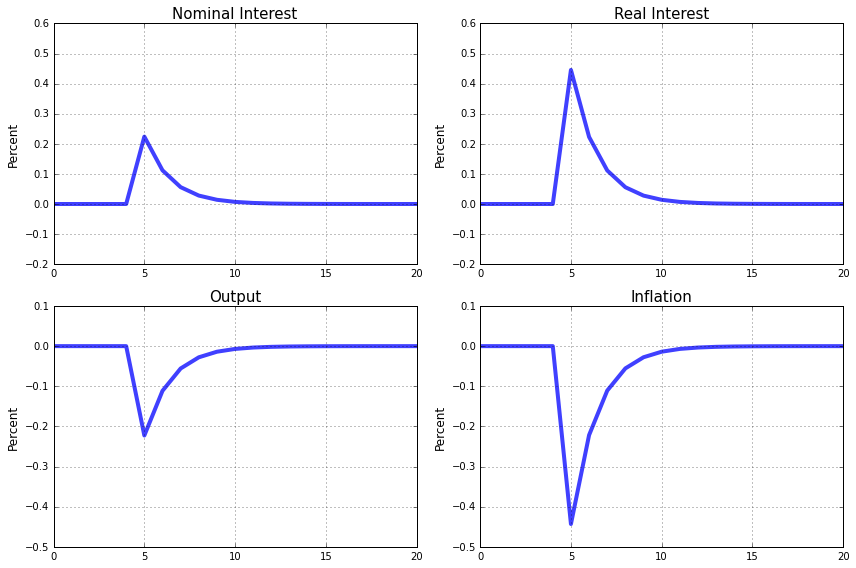

In [9]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)
ax1.set_ylabel('Percent',fontsize=12)
ax2.set_ylabel('Percent',fontsize=12)
ax3.set_ylabel('Percent',fontsize=12)
ax4.set_ylabel('Percent',fontsize=12)

ax1.set_title('Nominal Interest',fontsize=15)
ax2.set_title('Real Interest',fontsize=15)
ax3.set_title('Output',fontsize=15)
ax4.set_title('Inflation',fontsize=15)

(model.irs['e_v']['i']*400).plot(ax=ax1,lw=4,alpha=0.75,grid=True)
(model.irs['e_v']['r']*400).plot(ax=ax2,lw=4,alpha=0.75,grid=True)
(model.irs['e_v']['y']*100).plot(ax=ax3,lw=4,alpha=0.75,grid=True)
(model.irs['e_v']['pi']*400).plot(ax=ax4,lw=4,alpha=0.75,grid=True)

ax1.set_ylim([-0.2,0.6])
ax2.set_ylim([-0.2,0.6])
ax3.set_ylim([-0.5,0.1])
ax4.set_ylim([-0.5,0.1])

fig.tight_layout()

# Save image and make LaTex figure
figName = '015_intro_nk_modeling_monetary_shock'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120,transparent=True)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Monetary policy shock.} Impulse responses \
of the exogenous component of inflation, the nominal interest rate, output, and inflation to a 0.25 percent shock to the \
exogenous component of monetary policy. Inflation and interest rates are annualized.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 9cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

In [10]:
print(model.irs['e_v'][['y']].abs().max()*100)
print(model.irs['e_v'][['i','r','pi']].abs().max()*400)

y    0.222715
dtype: float64
i     0.223823
r     0.445429
pi    0.443213
dtype: float64


## Stochastic Simulation

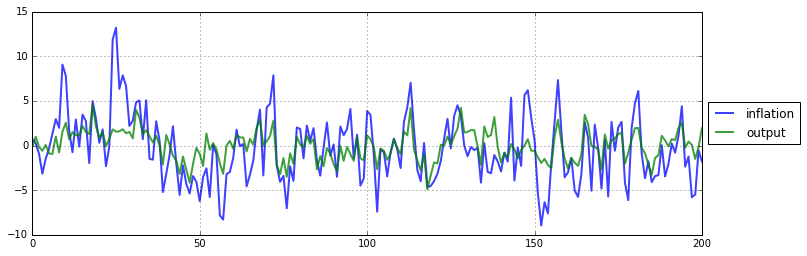

In [11]:
model.stoch_sim(T=201,seed=126,cov_mat = [[parameters['sigma_g']**2,0,0],[0,parameters['sigma_v']**2,0],[0,0,parameters['sigma_u']**2]])

fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,1,1)
(model.simulated['pi']*400).plot(ax=ax,lw=2,alpha=0.75,grid=True,label='inflation')
(model.simulated['y']*100).plot(ax=ax,lw=2,alpha=0.75,grid=True,label='output')

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Save image and make LaTex figure
figName = '015_intro_nk_stochastic_simulation'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120,transparent=True)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Stochastic simulation} of the new-Keynesian model. Inflation is annualized.\'}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 9cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()